In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
# from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [12]:
# Import data 
data_path_news = Path("dataset") / "news.tsv"
data_path_user_interaction = Path("dataset") / "behaviors.tsv"
data_path_news_embeddings = Path("dataset") / "article_embeddings.npy"

news_articles = pd.read_csv(
    data_path_news,
    sep="\t",
    header=None
)
news_articles.columns = ['News_ID', 
                         'Category', 
                         'Subcategory',
                         'Title',
                         'Abstract',
                         'URL',
                         'Title Entities',
                         'Abstract Entities']

users_interaction = pd.read_csv(
    data_path_user_interaction,
    sep="\t",
    header=None
)
users_interaction.columns = ['No.',
                            'User_ID',
                            'Time_Stamp',
                            'History',
                            'Impression']

In [13]:
# Feature Engineering: Transforming Article Features into Embeddings

# Uncomment to use the model to download the model to transform articles into embeddings
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

news_articles["text_for_embedding"] = (
    "Category: " + news_articles["Category"].fillna("") + ". " +
    "Subcategory: " + news_articles["Subcategory"].fillna("") + ". " +
    "Title: " + news_articles["Title"].fillna("") + ". " +
    "Abstract: " + news_articles["Abstract"].fillna("")
)

# article_embeddings = model.encode(
#     news_articles["text_for_embedding"].tolist(),
#     show_progress_bar=True
# )


article_embeddings = np.load(data_path_news_embeddings)
article_embedding_dict = {
    news_id: emb
    for news_id, emb in zip(news_articles["News_ID"], article_embeddings)
}

# History count feature
def get_history_count(history):
    if pd.isna(history) or history == "":
        return 0
    return len(history.split())

users_interaction['history_count'] = users_interaction['History'].apply(get_history_count)
users_interaction['history_count_norm'] = users_interaction['history_count'] / users_interaction['history_count'].max()

# Count how often the user reads each category
news_to_category = dict(zip(news_articles['News_ID'], news_articles['Category']))
all_categories = news_articles['Category'].unique().tolist()

def get_category_freq(history):
    freq = defaultdict(int)
    
    if pd.isna(history) or history == "":
        return np.zeros(len(all_categories))
    
    for article in history.split():
        category = news_to_category.get(article)
        if category:
            freq[category] += 1
    
    return np.array([freq[cat] for cat in all_categories])

users_interaction['category_freq'] = users_interaction['History'].apply(get_category_freq)


# Time Feature
users_interaction['Time_Stamp'] = pd.to_datetime(users_interaction['Time_Stamp'], format='%m/%d/%Y %I:%M:%S %p')
users_interaction['hour'] = pd.to_datetime(users_interaction['Time_Stamp']).dt.hour
users_interaction['dayofweek'] = pd.to_datetime(users_interaction['Time_Stamp']).dt.dayofweek
users_interaction['hour_norm'] = users_interaction['hour'] / 23.0
users_interaction['day_norm'] = users_interaction['dayofweek'] / 6.0

# Preprocessing User History Matrix
users_interaction['history_list'] = users_interaction['History'].fillna('').apply(lambda x: x.split())

def get_user_vector(history):
    vectors = [article_embedding_dict[a] for a in history if a in article_embedding_dict]
    if len(vectors) == 0:
        return np.zeros(384)
    return np.mean(vectors, axis=0)

users_interaction['user_vector'] = users_interaction['history_list'].apply(get_user_vector)

# Combine features from interaction dataset into user features
def build_user_features(row):
    time_features = np.array([
        row['hour_norm'],
        row['day_norm']
    ])
    
    frequency_features = np.array([
        row['history_count_norm']
    ])
    
    history_feature = row['user_vector']
    category_feature = row['category_freq']
    
    return np.concatenate([
        history_feature,
        time_features,
        frequency_features,
        category_feature
    ])
users_interaction['user_features'] = users_interaction.apply(build_user_features, axis=1)

In [14]:
# article_embedding_dict: {article_id: embedding_vector}
article_ids = list(article_embedding_dict.keys())
X_articles = np.array([article_embedding_dict[aid] for aid in article_ids])

# Reducing Dimensions
pca_64 = PCA(n_components=64, random_state=42)
X_articles_64 = pca_64.fit_transform(X_articles)

article_embedding_dict_64 = {
    aid: X_articles_64[i]
    for i, aid in enumerate(article_ids)
}
print("Original shape:", X_articles.shape)
print("Reduced shape:", X_articles_64.shape)

# Build matrix of user vectors
X_users = np.array(users_interaction["user_vector"].tolist())

# Project user vectors into the 64-dim PCA space
X_users_64 = pca_64.transform(X_users)

# Store back
users_interaction["user_vector_64"] = list(X_users_64)

print("Original user shape:", X_users.shape)
print("Reduced user shape:", X_users_64.shape)

print("Explained variance:", pca_64.explained_variance_ratio_.sum())

def parse_impressions(imp_str):
    if pd.isna(imp_str) or imp_str == "":
        return [], None
    
    candidates = []
    clicked = None
    for item in imp_str.split():
        if "-" not in item:
            continue
        aid, label = item.rsplit("-", 1)
        candidates.append(aid)
        if label == "1":
            clicked = aid
            
    return candidates, clicked

# Apply it to the entire dataset once
users_interaction[["candidate_ids", "clicked_id"]] = users_interaction["Impression"].apply(
    lambda x: pd.Series(parse_impressions(x))
)

Original shape: (51282, 384)
Reduced shape: (51282, 64)
Original user shape: (156965, 384)
Reduced user shape: (156965, 64)
Explained variance: 0.6074699


In [15]:
# Helper Functions
def get_user_embedding(history, article_embedding_dict, embedding_dim=64):
    if pd.isna(history) or history == "":
        return np.zeros(embedding_dim)
    
    article_ids = history.split()
    embs = [
        article_embedding_dict[aid]
        for aid in article_ids
        if aid in article_embedding_dict
    ]
    
    if len(embs) == 0:
        return np.zeros(embedding_dim)
    
    return np.mean(embs, axis=0)

def make_context(user_features, article_emb):
    return np.concatenate([user_features, article_emb])

In [16]:
# EpsilonGreedy
class DecayingEpsilonGreedyLinear:
    def __init__(self, d, initial_epsilon=1.0, decay_rate=0.001, lr=0.01):
        self.name = "DecayingEpsilonGreedyLinear"
        self.d = d
        self.theta = np.zeros(d)

        self.initial_epsilon = initial_epsilon
        self.decay_rate = decay_rate
        self.lr = lr

        self.t = 1
        self.last_x = None  # store chosen context

    def get_epsilon(self):
        return self.initial_epsilon / (1 + self.decay_rate * self.t)

    def predict(self, x):
        return np.dot(self.theta, x)

    def select_arm(self, user_features, candidate_article_ids, article_embedding_dict):
        epsilon = self.get_epsilon()

        valid_candidates = [
            aid for aid in candidate_article_ids
            if aid in article_embedding_dict
        ]

        if len(valid_candidates) == 0:
            self.last_x = None
            return None

        if np.random.rand() < epsilon:
            chosen_article = np.random.choice(valid_candidates)
            article_emb = article_embedding_dict[chosen_article]
            self.last_x = make_context(user_features, article_emb)
            return chosen_article

        best_score = -np.inf
        best_article = None
        best_x = None

        for aid in valid_candidates:
            article_emb = article_embedding_dict[aid]
            x = make_context(user_features, article_emb)
            score = self.predict(x)

            if score > best_score:
                best_score = score
                best_article = aid
                best_x = x

        self.last_x = best_x
        return best_article

    def update(self, chosen_article_id, reward):
        if self.last_x is None:
            return

        pred = self.predict(self.last_x)
        error = reward - pred

        self.theta += self.lr * error * self.last_x
        self.t += 1

In [17]:
class LinUCB:
    def __init__(self, d, alpha=1.0):
        self.name = "LinUCB"
        self.d = d
        self.alpha = alpha

        # Cache the inverse and the weights directly
        self.A_inv = {}   # article_id -> d x d matrix (inverse)
        self.b = {}       # article_id -> d vector
        self.theta = {}   # article_id -> d vector

    def _init_arm(self, article_id):
        if article_id not in self.A_inv:
            self.A_inv[article_id] = np.eye(self.d)
            self.b[article_id] = np.zeros(self.d)
            self.theta[article_id] = np.zeros(self.d)

    def select_arm(self, user_features, candidate_article_ids, article_embedding_dict):
        self.last_context = {}  # cache for this timestep

        best_score = -np.inf
        best_article = None

        for aid in candidate_article_ids:
            self._init_arm(aid)

            A_inv_a = self.A_inv[aid]
            theta_a = self.theta[aid]

            article_emb = article_embedding_dict[aid]
            x = make_context(user_features, article_emb)
            self.last_context[aid] = x

            # Now just basic O(d^2) matrix multiplications
            mean_reward = x @ theta_a
            uncertainty = np.sqrt(x @ A_inv_a @ x)
            score = mean_reward + self.alpha * uncertainty

            if score > best_score:
                best_score = score
                best_article = aid

        return best_article

    def update(self, chosen_article_id, reward):
        self._init_arm(chosen_article_id)

        x = self.last_context[chosen_article_id]

        # Use Sherman-Morrison to update the inverse directly
        A_inv = self.A_inv[chosen_article_id]
        
        Ax = A_inv @ x
        numerator = np.outer(Ax, Ax)
        denominator = 1.0 + (x @ Ax)
        
        self.A_inv[chosen_article_id] -= numerator / denominator
        self.b[chosen_article_id] += reward * x
        
        # Update theta for future reads
        self.theta[chosen_article_id] = self.A_inv[chosen_article_id] @ self.b[chosen_article_id]

In [18]:
class LinearThompsonSampling:
    def __init__(self, d, lambda_=1.0, v=0.3):
        self.name = "LinearThompsonSampling"
        self.d = d
        self.lambda_ = lambda_
        self.v = v

        self.A_inv = {}
        self.b = {}
        self.mu = {}
        self.last_context = {}

    def _init_arm(self, aid):
        if aid not in self.A_inv:
            # The inverse of lambda * I is (1/lambda) * I
            self.A_inv[aid] = (1.0 / self.lambda_) * np.eye(self.d)
            self.b[aid] = np.zeros(self.d)
            self.mu[aid] = np.zeros(self.d)

    def select_arm(self, user_features, candidate_article_ids, article_embedding_dict):
        best_score = -np.inf
        best_article = None

        self.last_context = {}

        for aid in candidate_article_ids:
            self._init_arm(aid)

            # A_inv is already computed for us
            cov = (self.v ** 2) * self.A_inv[aid]

            # Multivariate Normal is still the bottleneck, but without np.linalg.inv it's many times faster
            theta_sample = np.random.multivariate_normal(self.mu[aid], cov)

            x = make_context(user_features, article_embedding_dict[aid])
            self.last_context[aid] = x

            score = x @ theta_sample

            if score > best_score:
                best_score = score
                best_article = aid

        return best_article

    def update(self, chosen_article_id, reward):
        if chosen_article_id is None:
            return

        self._init_arm(chosen_article_id)

        x = self.last_context.get(chosen_article_id)
        if x is None:
            return

        A_inv = self.A_inv[chosen_article_id]

        # Use Sherman-Morrison to update the inverse directly
        Ax = A_inv @ x
        numerator = np.outer(Ax, Ax)
        denominator = 1.0 + (x @ Ax)

        self.A_inv[chosen_article_id] -= numerator / denominator
        self.b[chosen_article_id] += reward * x
        
        # Update mu
        self.mu[chosen_article_id] = self.A_inv[chosen_article_id] @ self.b[chosen_article_id]


In [19]:
def test_algo(algo, interaction_df, article_embedding_dict, user_col="user_vector_64"):
    results = []
    cumulative_reward = 0.0

    # itertuples() is substantially faster than iterrows()
    for t, row in enumerate(interaction_df.itertuples(), start=1):
        
        # Access properties using dot notation based on column names
        user_features = getattr(row, user_col)
        candidate_article_ids = row.candidate_ids
        clicked_article_id = row.clicked_id
        
        # Filter valid candidates (only those in our embedding dictionary)
        valid_candidates = [aid for aid in candidate_article_ids if aid in article_embedding_dict]

        if len(valid_candidates) == 0:
            continue

        # Select arm
        chosen_article_id = algo.select_arm(
            user_features,
            valid_candidates,
            article_embedding_dict
        )

        reward = 1 if chosen_article_id == clicked_article_id else 0

        # Update algorithm
        algo.update(chosen_article_id, reward)

        cumulative_reward += reward

        results.append({
            "Algorithm": algo.name,
            "Timestep": t,
            "Chosen_Arm": chosen_article_id,
            "Reward": reward,
            "Cumulative_Reward": cumulative_reward
        })

    return pd.DataFrame(results)

In [ ]:
# Simulation
simulation = 10

# Fixed evaluation subset
users_interaction_5000 = users_interaction.iloc[:5000].copy()
interaction_df = users_interaction_5000

# Context dimension:
# full user feature + article embedding
context_dim = len(interaction_df.iloc[0]["user_vector_64"]) + X_articles_64.shape[1]

# ----- Greedy Epsilon -----
eps_runs = []

for sim in range(simulation):
    eps_greedy = DecayingEpsilonGreedyLinear(
        d=context_dim,
        initial_epsilon=1.0,
        decay_rate=0.001
    )
    eps_result = test_algo(eps_greedy, interaction_df, article_embedding_dict_64)
    eps_result["Simulation"] = sim + 1
    eps_runs.append(eps_result)

results_eps = pd.concat(eps_runs, ignore_index=True)

results_eps_avg = (
    results_eps.groupby("Timestep", as_index=False)
    .agg({
        "Reward": "mean",
        "Cumulative_Reward": "mean"
    })
)
results_eps_avg["Algorithm"] = "Decaying Epsilon Greedy"

# ----- LinUCB-----
linucb = LinUCB(d=context_dim, alpha=1.0)
results_linucb = test_algo(linucb, interaction_df, article_embedding_dict_64)

# ----- Thompson Sampling-----
ts_runs = []

for sim in range(simulation):
    ts = LinearThompsonSampling(d=context_dim, lambda_=1.0, v=0.3)
    ts_result = test_algo(ts, interaction_df, article_embedding_dict_64)
    ts_result["Simulation"] = sim + 1
    ts_runs.append(ts_result)

results_ts = pd.concat(ts_runs, ignore_index=True)

# Average TS results by timestep
results_ts_avg = (
    results_ts.groupby("Timestep", as_index=False)
    .agg({
        "Reward": "mean",
        "Cumulative_Reward": "mean"
    })
)
results_ts_avg["Algorithm"] = "Linear Thompson Sampling"



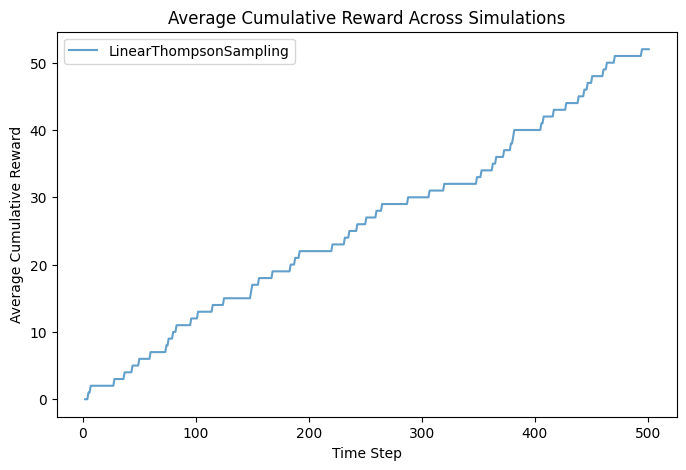

In [ ]:
# Combine all results
all_results = []

# LinUCB:
linucb_plot = results_linucb.copy()
linucb_plot["Algorithm"] = "LinUCB"
linucb_plot["Simulation"] = 1
all_results.append(linucb_plot)

# Thompson Sampling
ts_plot = results_ts.copy()
ts_plot["Algorithm"] = "Linear Thompson Sampling"
all_results.append(ts_plot)

# Epsilon Greedy
eps_plot = results_eps.copy()
eps_plot["Algorithm"] = "Decaying Epsilon Greedy"
all_results.append(eps_plot)

# Final combined dataframe
result_df = pd.concat(all_results, ignore_index=True)

# Compute cumulative reward per algorithm per simulation
result_df["cumulative_reward"] = (
    result_df
    .sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"])["Reward"]
    .cumsum()
)

# Average cumulative reward across simulations
avg_cum_reward = (
    result_df
    .groupby(["Algorithm", "Timestep"])["cumulative_reward"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8, 5))

for algo in avg_cum_reward["Algorithm"].unique():
    data = avg_cum_reward[avg_cum_reward["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["cumulative_reward"], label=algo)

plt.xlabel("Time Step")
plt.ylabel("Average Cumulative Reward")
plt.title("Average Cumulative Reward Across Algorithms")
plt.legend()
plt.show()

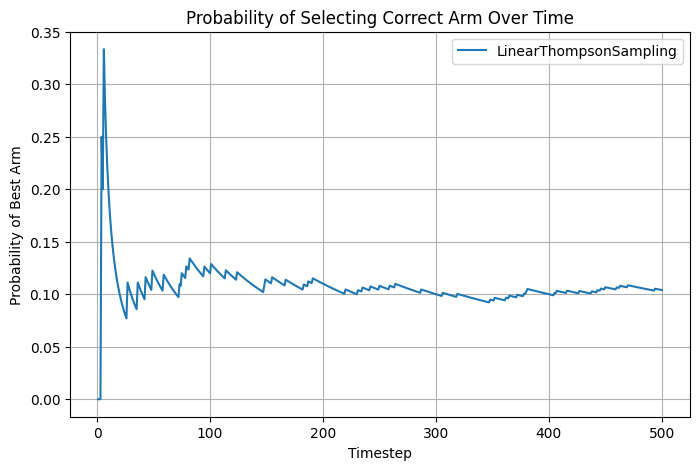

In [ ]:
# Step per simulation
result_df["Step"] = (
    result_df
    .sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"])
    .cumcount() + 1
)

# Cumulative correct per simulation
result_df["Cumulative_Correct"] = (
    result_df
    .sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"])["Reward"]
    .cumsum()
)

# Probability per simulation
result_df["Prob_Best_Arm"] = (
    result_df["Cumulative_Correct"] / result_df["Step"]
)

# Average across simulations
avg_prob = (
    result_df
    .groupby(["Algorithm", "Timestep"])["Prob_Best_Arm"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8, 5))

for algo in avg_prob["Algorithm"].unique():
    data = avg_prob[avg_prob["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["Prob_Best_Arm"], label=algo)

plt.xlabel("Timestep")
plt.ylabel("Probability of Best Arm")
plt.title("Probability of Selecting Correct Arm (Averaged)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
candidate_counts = []

for imp in users_interaction_5000["Impression"]:
    articles = [x.split("-")[0] for x in imp.split()]
    candidate_counts.append(len(articles))

print("Average # candidates:", np.mean(candidate_counts))
print("Random baseline:", 1 / np.mean(candidate_counts))

Average # candidates: 35.662
Random baseline: 0.028041052100274803
